<a href="https://colab.research.google.com/github/Kunal-7O7/Machine-Learning-Algorithms/blob/main/Harierary_Cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN


In [ ]:
df=pd.read_csv("Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.shape

(200, 5)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df1=df.drop(["CustomerID","Genre","Age"],axis=1)

In [ ]:
df1.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
# Scalling the Features
df1_scaled=StandardScaler().fit_transform(df1)

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage


In [ ]:
linked=(linkage(df1_scaled,method="ward"))

In [ ]:
agg_m=AgglomerativeClustering()

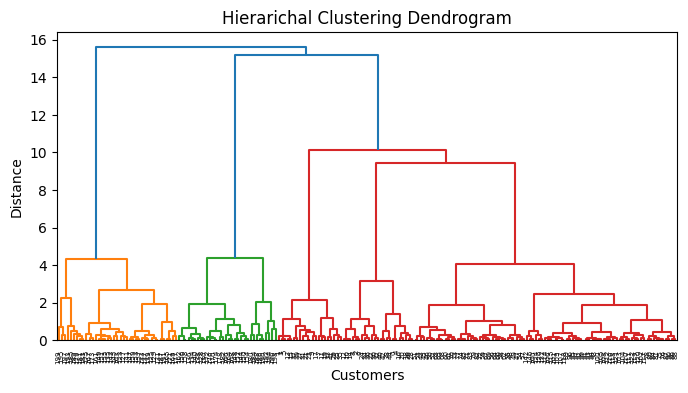

In [ ]:
plt.figure(figsize=(8,4))
dendrogram(linked)
plt.title("Hierarichal Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [ ]:
# As We can see that dendogram is showing the 5 cluster as good to cut it

labels=AgglomerativeClustering(n_clusters=5,linkage="ward").fit_predict(df1_scaled)

In [ ]:
labels

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [ ]:
df1["cluster"]=labels

In [ ]:
df1.head()

,Annual Income (k$),Spending Score (1-100),cluster
0,15,39,4
1,15,81,3
2,16,6,4
3,16,77,3
4,17,40,4


In [ ]:
df1.groupby("cluster")[["Annual Income (k$)","Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
cluster,,
0,89.406250,15.593750
1,86.538462,82.128205
2,55.811765,49.129412
3,25.095238,80.047619
4,26.304348,20.913043


In [ ]:
df1["cluster"].value_counts().sort_index(ascending=True)

,count
cluster,
0,32
1,39
2,85
3,21
4,23


In [ ]:
df1["Age"]=df["Age"]

In [ ]:
df1.head()

,Annual Income (k$),Spending Score (1-100),cluster,Age
0,15,39,4,19
1,15,81,3,21
2,16,6,4,20
3,16,77,3,23
4,17,40,4,31


In [ ]:
customer_profiling=df1.groupby("cluster")[["Annual Income (k$)","Spending Score (1-100)","Age"]].mean()

In [ ]:
customer_profiling

,Annual Income (k$),Spending Score (1-100),Age
cluster,,,
0,89.406250,15.593750,41.000000
1,86.538462,82.128205,32.692308
2,55.811765,49.129412,42.482353
3,25.095238,80.047619,25.333333
4,26.304348,20.913043,45.217391


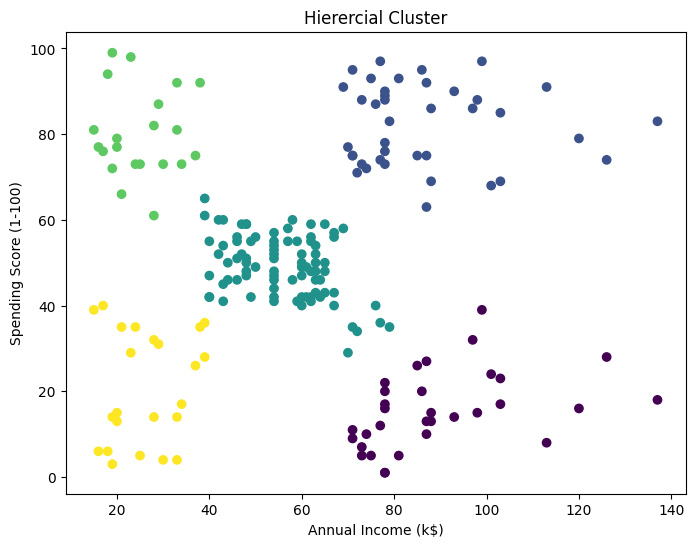

In [ ]:
# Vishualizing the cluster
plt.figure(figsize=(8,6))
plt.scatter(df1["Annual Income (k$)"],
            df1["Spending Score (1-100)"],
            c=labels
            )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hierercial Cluster")

plt.show()

In [ ]:
# Showing the shiloutte Score
from sklearn.metrics import silhouette_score

In [ ]:
sil_sc=silhouette_score(df1_scaled,labels)

print(sil_sc)

0.5538089226688662


DBSCAN


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [ ]:
x,y=make_moons(n_samples=300,noise=.08,random_state=42)

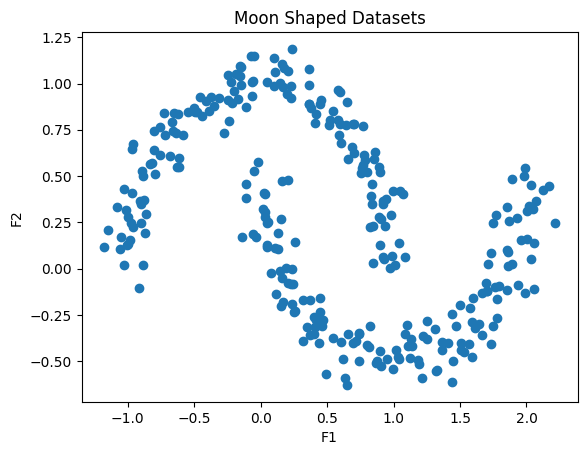

In [ ]:
plt.scatter(x[:,0],x[:,1])
plt.title("Moon Shaped Datasets")
plt.xlabel("F1")
plt.ylabel("F2")
plt.show()

In [ ]:
model_db=DBSCAN(eps=.10,min_samples=5)
labels=model_db.fit_predict(x)
labels


array([ 0, -1, -1,  1,  2,  2,  3, 14,  4,  5, -1,  6,  2, -1,  5,  2,  7,
        0, -1, 12,  8,  9, 10, 10, 14, 11, -1,  7, 12, 10,  1, 12, 13,  1,
        0,  9,  4,  8, -1,  8,  8, -1, -1,  8,  8, -1,  2,  2, 14,  2,  5,
       -1,  2,  8,  7, -1,  8,  8,  3, 13,  2,  6,  4,  5,  5, 13, 13, -1,
       -1, 16,  8, 15,  2,  3, 15, -1,  8,  8,  8,  7, 12, -1, 13,  9,  8,
       14,  9,  8,  1,  1,  3,  8,  8,  2, 11,  1, 16, -1, -1,  8,  2,  8,
       13, 16, 17,  2, -1,  1,  5,  8, 15, 17,  8, 10, -1, 14, 15,  7,  3,
        0,  6, 12, 16,  5, 15, 18, 11, 15,  3, -1, 15, 14, 12,  9, -1, 17,
       -1, 16,  5,  4,  9, 15,  5,  9, -1, 18,  9,  8,  1,  8, 17, 14,  2,
       12, -1, -1,  2,  8,  3,  8,  0, 12,  1, 13, 13, 15, -1, 18, 12,  6,
        8,  0, 10, 11, -1, -1, -1, 13, -1, 15,  3,  4, -1, 17,  8, 17, -1,
       12,  8, 11,  8, -1,  2, -1, 10,  1, -1, 17, 13,  2,  4,  9, 13,  0,
       -1,  0,  7, 15,  8, 15,  9, -1,  4,  8, 18, -1, 11, -1, 12, 13, -1,
       -1,  0, -1, 13, -1

Text(0, 0.5, 'F2')

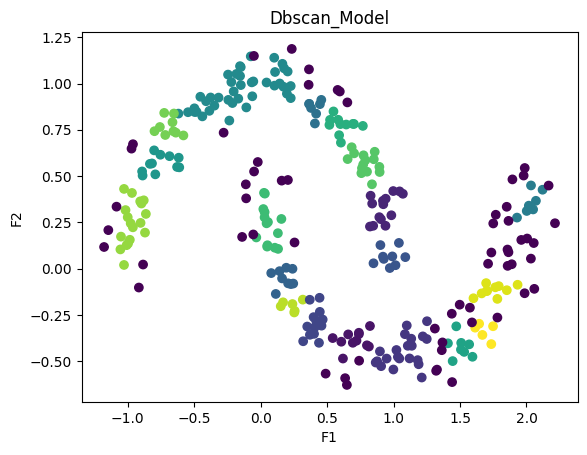

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels)
plt.title("Dbscan_Model")
plt.xlabel("F1")
plt.ylabel("F2")

In [ ]:
model_db1=DBSCAN(eps=.10,min_samples=5)
labels1=model_db1.fit_predict(x)
labels1

array([ 0, -1, -1,  1,  2,  2,  3, 14,  4,  5, -1,  6,  2, -1,  5,  2,  7,
        0, -1, 12,  8,  9, 10, 10, 14, 11, -1,  7, 12, 10,  1, 12, 13,  1,
        0,  9,  4,  8, -1,  8,  8, -1, -1,  8,  8, -1,  2,  2, 14,  2,  5,
       -1,  2,  8,  7, -1,  8,  8,  3, 13,  2,  6,  4,  5,  5, 13, 13, -1,
       -1, 16,  8, 15,  2,  3, 15, -1,  8,  8,  8,  7, 12, -1, 13,  9,  8,
       14,  9,  8,  1,  1,  3,  8,  8,  2, 11,  1, 16, -1, -1,  8,  2,  8,
       13, 16, 17,  2, -1,  1,  5,  8, 15, 17,  8, 10, -1, 14, 15,  7,  3,
        0,  6, 12, 16,  5, 15, 18, 11, 15,  3, -1, 15, 14, 12,  9, -1, 17,
       -1, 16,  5,  4,  9, 15,  5,  9, -1, 18,  9,  8,  1,  8, 17, 14,  2,
       12, -1, -1,  2,  8,  3,  8,  0, 12,  1, 13, 13, 15, -1, 18, 12,  6,
        8,  0, 10, 11, -1, -1, -1, 13, -1, 15,  3,  4, -1, 17,  8, 17, -1,
       12,  8, 11,  8, -1,  2, -1, 10,  1, -1, 17, 13,  2,  4,  9, 13,  0,
       -1,  0,  7, 15,  8, 15,  9, -1,  4,  8, 18, -1, 11, -1, 12, 13, -1,
       -1,  0, -1, 13, -1

Text(0, 0.5, 'F2')

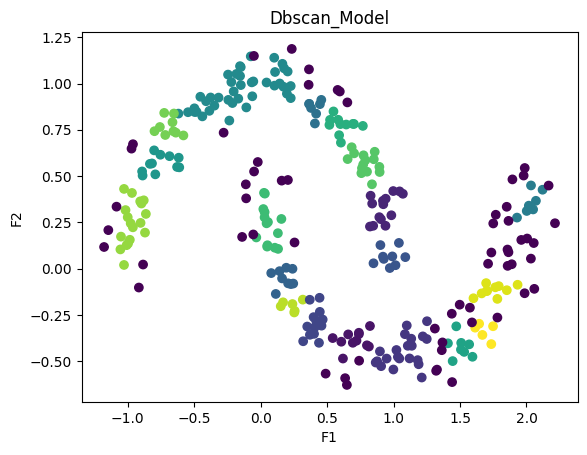

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels1)
plt.title("Dbscan_Model")
plt.xlabel("F1")
plt.ylabel("F2")

In [ ]:
model_db2=DBSCAN(eps=.20,min_samples=5)
labels2=model_db2.fit_predict(x)


Text(0, 0.5, 'F2')

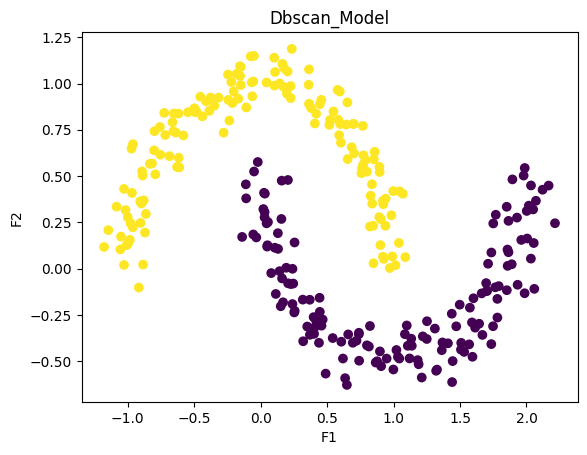

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels2)
plt.title("Dbscan_Model")
plt.xlabel("F1")
plt.ylabel("F2")

In [ ]:
model_db3=DBSCAN(eps=.15,min_samples=5)
labels3=model_db3.fit_predict(x)


Text(0, 0.5, 'F2')

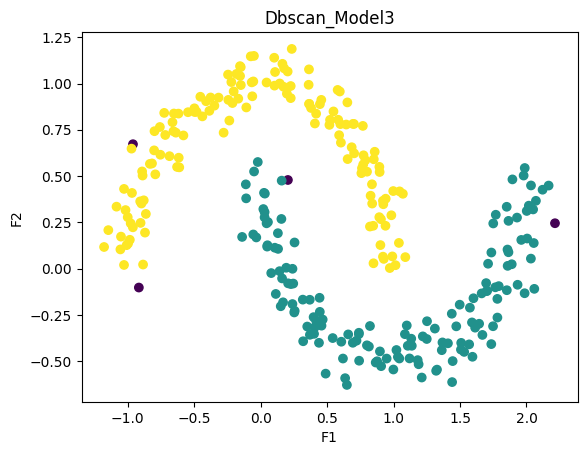

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels3)
plt.title("Dbscan_Model3")
plt.xlabel("F1")
plt.ylabel("F2")

In [ ]:
model_db4=DBSCAN(eps=.10,min_samples=5)
labels4=model_db4.fit_predict(x)


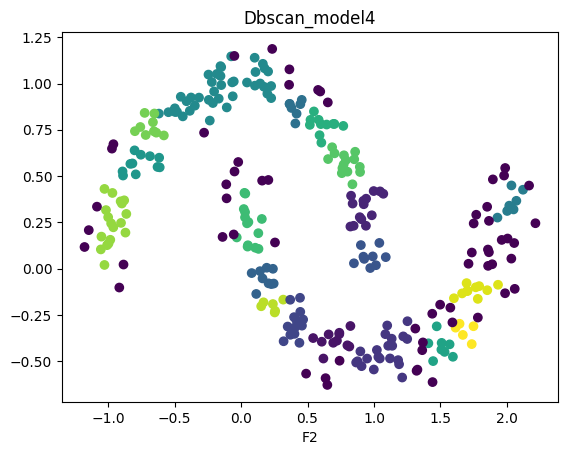

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels4)
plt.title("Dbscan_model4")
plt.xlabel("F1")
plt.xlabel("F2")
plt.show()

In [ ]:
noise_points=np.sum(labels==-1)
print(noise_points)

60


In [ ]:
np.unique(labels)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18])

In [ ]:
model_db5=DBSCAN(eps=.30,min_samples=5)
labels5=model_db5.fit_predict(x)

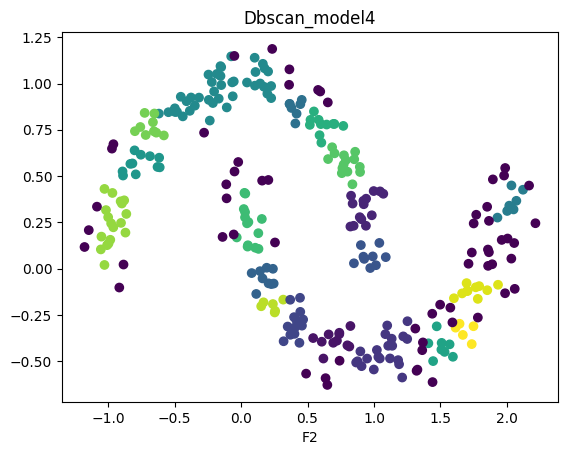

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels4)
plt.title("Dbscan_model4")
plt.xlabel("F1")
plt.xlabel("F2")
plt.show()

In [ ]:
model_db6=DBSCAN(eps=.20,min_samples=15)
labels6=model_db6.fit_predict(x)

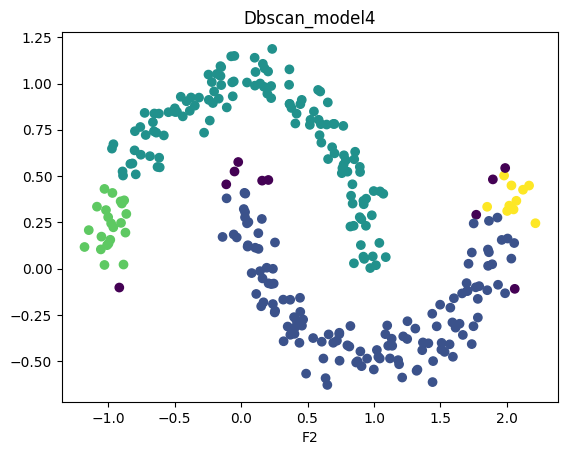

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels6)
plt.title("Dbscan_model4")
plt.xlabel("F1")
plt.xlabel("F2")
plt.show()

In [ ]:
model_db7=DBSCAN(eps=.16,min_samples=10)
labels7=model_db7.fit_predict(x)

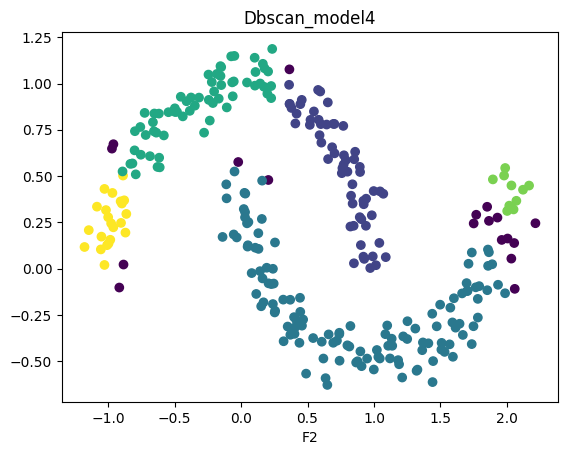

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels7)
plt.title("Dbscan_model4")
plt.xlabel("F1")
plt.xlabel("F2")
plt.show()

In [ ]:
model_db8=DBSCAN(eps=.14,min_samples=8)
labels8=model_db8.fit_predict(x)

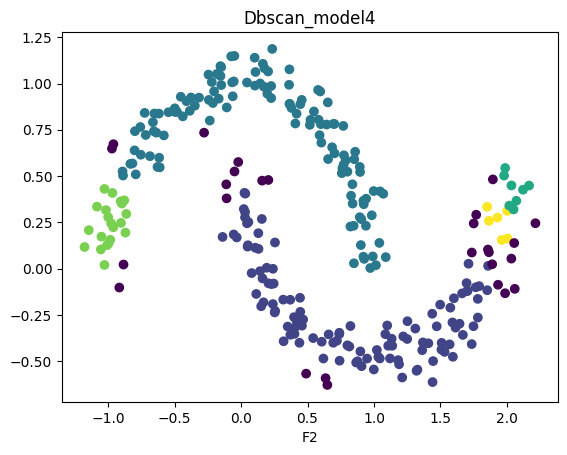

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels8)
plt.title("Dbscan_model4")
plt.xlabel("F1")
plt.xlabel("F2")
plt.show()

In [ ]:
model_db9=DBSCAN(eps=.15,min_samples=5)
labels9=model_db9.fit_predict(x)

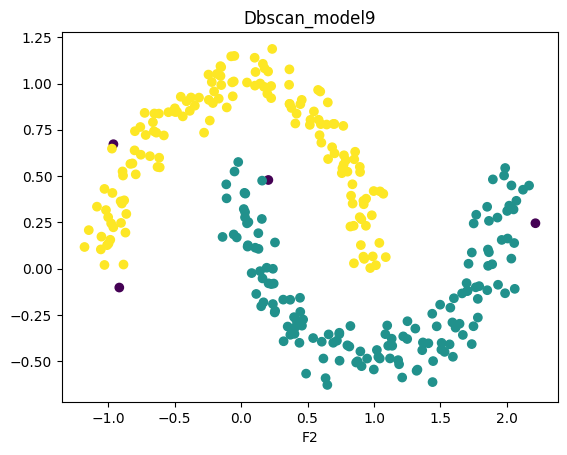

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels9)
plt.title("Dbscan_model9")
plt.xlabel("F1")
plt.xlabel("F2")
plt.show()

In [ ]:
model_db10=DBSCAN(eps=.10,min_samples=3)
labels10=model_db10.fit_predict(x)

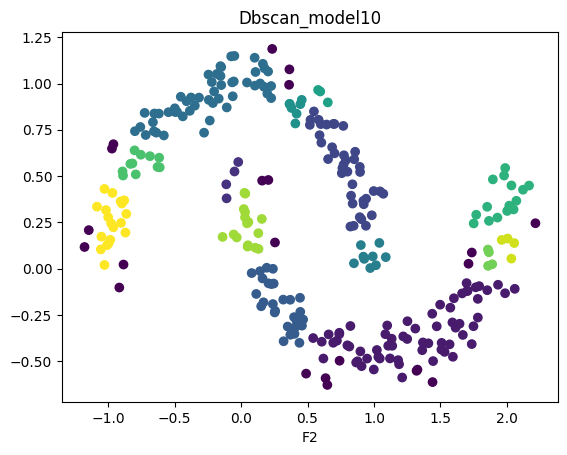

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels10)
plt.title("Dbscan_model10")
plt.xlabel("F1")
plt.xlabel("F2")
plt.show()

In [ ]:
uni,count=np.unique(labels10,return_counts=True)

for uni,count in zip(uni,count):
  print(uni,count)

-1 22
0 65
1 4
2 39
3 29
4 53
5 9
6 7
7 3
8 15
9 11
10 4
11 16
12 4
13 19


In [ ]:
noise=np.sum(labels10==-1)
print(noise)

22


In [ ]:
model_db11=DBSCAN(eps=.10,min_samples=7)
labels11=model_db11.fit_predict(x)

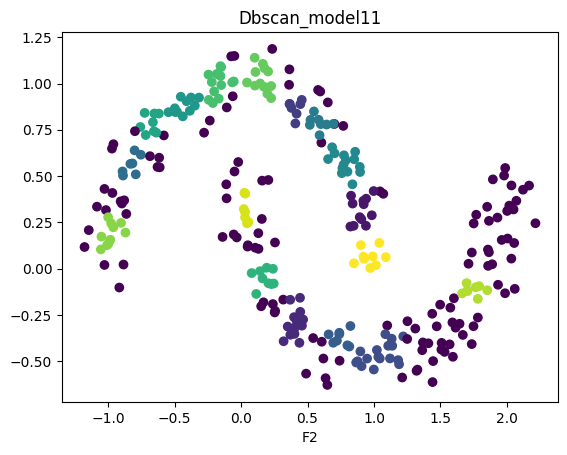

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels11)
plt.title("Dbscan_model11")
plt.xlabel("F1")
plt.xlabel("F2")
plt.show()

In [ ]:
model_db12=DBSCAN(eps=0.12,min_samples=5)
labels12=model_db12.fit_predict(x)

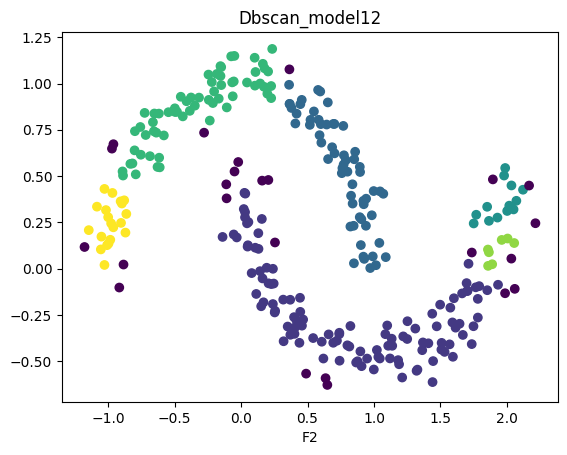

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels12)
plt.title("Dbscan_model12")
plt.xlabel("F1")
plt.xlabel("F2")
plt.show()

In [ ]:
cluster=np.unique(labels12)
print(cluster)

[-1  0  1  2  3  4  5]


In [ ]:
unique,counts=np.unique(labels12,return_counts=True)
for unique,counts in zip(unique,counts):
  print(unique,counts)

-1 24
0 113
1 59
2 13
3 64
4 7
5 20


In [ ]:
df1=pd.DataFrame(x,columns=["F1","F2"])
df2=pd.DataFrame(y,columns=["T1"])

In [ ]:
df5=pd.concat([df1,df2],axis=1)
df5.head()

,F1,F2,T1
0,0.658801,-0.355963,1
1,1.986302,-0.133490,1
2,-0.111623,0.455081,1
3,0.905008,0.266798,0
4,1.181619,-0.494965,1


In [ ]:
x_scaled=StandardScaler().fit_transform(x)

In [ ]:
model13=DBSCAN(eps=.12,min_samples=5)
labels13=model13.fit_predict(x_scaled)

Text(0, 0.5, "['F2']")

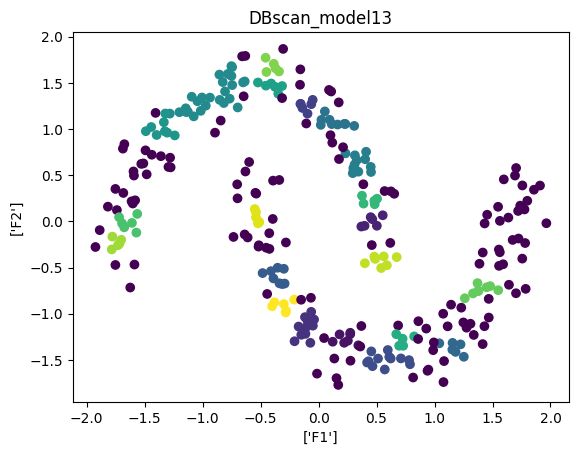

In [ ]:
  plt.scatter(x_scaled[:,0],x_scaled[:,1],c=labels13)
plt.title("DBscan_model13")
plt.xlabel(["F1"])
plt.ylabel(["F2"])


In [ ]:
# How to choose the eps number
from sklearn.neighbors import NearestNeighbors

In [ ]:
nearestN=NearestNeighbors(n_neighbors=5)
neighbors=nearestN.fit(x_scaled)

In [ ]:
distance,indic=neighbors.kneighbors(x_scaled)

In [ ]:
k_dis=np.sort(distance)

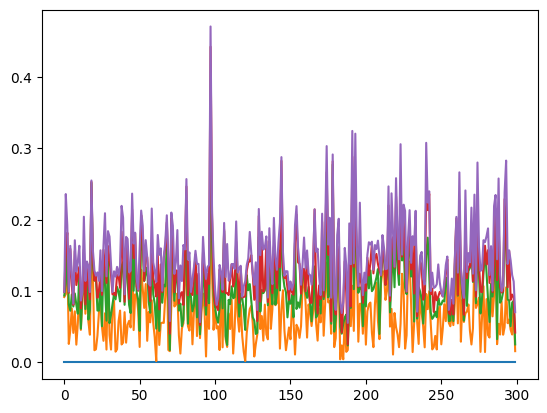

In [ ]:
plt.plot(k_dis)